# Data preprocessing

In this notebook we will preprocess our data. This includes dropping unneccesary variables, creating pipeline for preprocess numerical data, categorical and creating new variables. The output of this notebook will be input of modeling notebook.

## Imports and droppings

Firstly we will import libraries, data and drop unimportant variables and also `Complain variable`, which as we saw earlier is almost 100% correlated with target variable and would be able to make our model not representative

In [66]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

data = pd.read_csv("data.csv")
col_to_drop = ["RowNumber", "CustomerId", "Surname", "Complain", "Exited"]
X = data.drop(col_to_drop, axis=1)
y = data['Exited']

## Feature Engineering: Derived Variables

To improve the predictive power of the churn model, we have created three new interaction variables. These features aim to capture behavioral patterns that are not visible when looking at `Age`, `Balance`, or `CreditScore` in isolation.

### 1. BalanceSalaryRatio
This variable represents the ratio of the customer's account balance to their estimated salary.

$$\text{BalanceSalaryRatio} = \frac{\text{Balance}}{\text{EstimatedSalary}}$$

* **Logic:** It serves as a proxy for the customer's financial dependence on the bank.
* **Interpretation:**
    * A **high ratio** suggests this is a primary savings account, making the customer financially attached and less likely to churn.
    * A **low ratio** suggests the customer uses the bank only for transactional purposes or holds their savings elsewhere, increasing the risk of churn.

---

### 2. TenureByAge
This variable normalizes the number of years a customer has been with the bank (`Tenure`) by their `Age`.

$$\text{TenureByAge} = \frac{\text{Tenure}}{\text{Age}}$$

* **Logic:** It measures loyalty relative to the customer's life stage.
* **Interpretation:**
    * A 25-year-old with a 5-year tenure is significantly more loyal (relative to their adult life) than a 60-year-old with the same tenure.
---

### 3. CreditScoreGivenAge
This variable assesses the customer's credit score relative to their age.

$$\text{CreditScoreGivenAge} = \frac{\text{CreditScore}}{\text{Age}}$$

* **Logic:** It contextualizes creditworthiness. Building a high credit score takes time; therefore, a high score at a young age is a strong indicator of financial responsibility.
* **Interpretation:**
    * **High values** indicate young customers with excellent credit behavior (potential VIPs).
    * **Low values** among older customers may indicate financial distress or instability, which can often trigger churn.


In [67]:
X['BalanceSalaryRatio'] = np.where( X['EstimatedSalary'] == 0, 0, X['Balance'] / X['EstimatedSalary'])
X['TenureByAge'] = X['Tenure'] / X['Age']
X['CreditScoreGivenAge'] = X['CreditScore'] / X['Age']

## Data Preprocessing Pipeline

We implemented a unified **Scikit-Learn Pipeline** to automate feature encoding and scaling. First we automate splitting data for numerical columns, binary categorical columns and multi-class categorical columns. After that, we create pipeline that consists of two sequential steps:

### 1. Column Transformation
We apply specific transformations based on the data type:
* **Multi-Class Categoricals**: Transformed using **One-Hot Encoding** (creating dummy variables).
* **Binary Categoricals**: Transformed using **Ordinal Encoding** (mapping to 0/1).
* **Numerical Features**: Passed through initially to retain their original values before scaling.

### 2. Global Scaling
* **StandardScaler**: Applied to the entire processed dataset. This normalizes all features to have a mean of 0 and a standard deviation of 1, which is essential for model stability.

In [ ]:
# auto splitting columns for reproducibility
cat_cols = X.select_dtypes(include=['object']).columns
    
binary_cat_cols = []    
multi_cat_cols = [] 

for col in cat_cols:
    n_unique = X[col].nunique() # number of unique values in the column
    
    if n_unique == 2:   
        binary_cat_cols.append(col)  # if only two unique values, it's binary
    elif n_unique > 2:
        multi_cat_cols.append(col) # if more than two unique values, it's multi-category

num_cols = X.columns[~X.columns.isin(multi_cat_cols + binary_cat_cols)]


# 1. ColunsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('multi', OneHotEncoder(handle_unknown='ignore', sparse_output=False), multi_cat_cols),
        ('binary', OrdinalEncoder(), binary_cat_cols)
    ],
   
    verbose_feature_names_out=False # to avoid prefixes in feature names
)

# 2. Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('scaler', StandardScaler())      
])
pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('multi', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

## Last Comment
Summing up, firsly we imported our data and dropped target feature and also unneccesary variables. Then, we created 3 new features. After that we wrote column transformer, which depending on column type did something different. 
At the end, we connected final pipeline.
Everything, which was presented in this notebook has been implemented in utils.py as a funcion, which will be imported in the third part of our project. It has been done for reproducibility. 

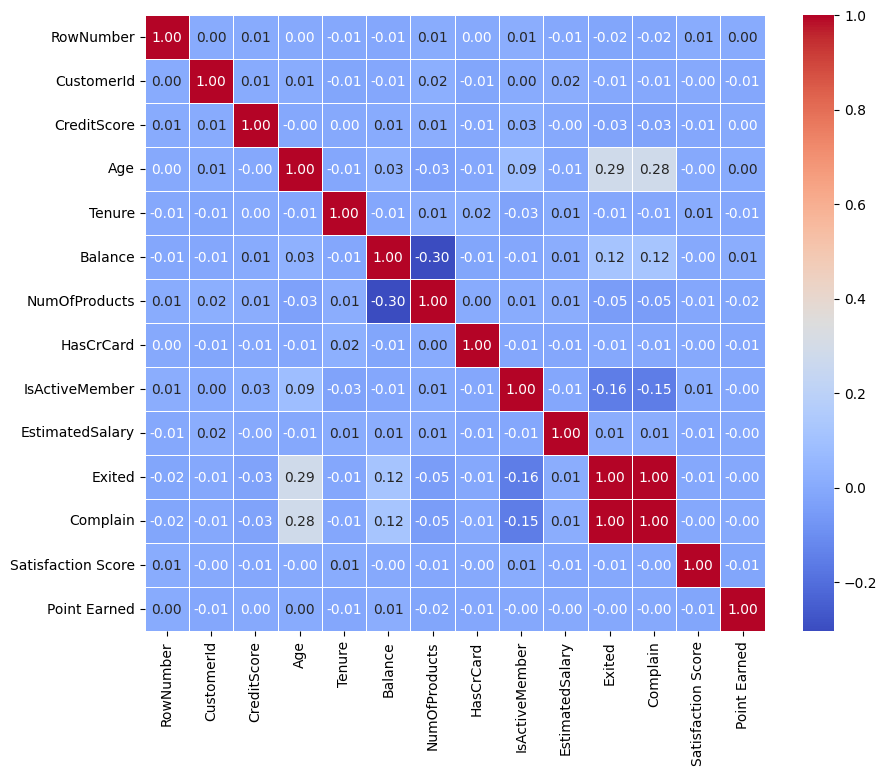

In [ ]:
# testing cor of new features

import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,         
    cmap='coolwarm',    
    fmt=".2f",       
    linewidths=0.5,    
    vmin=-1, vmax=1  
)

plt.show()